In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [223]:
df=pd.read_csv('diabetes.csv')

In [224]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,16,176,71,11,0,44.9,0.212,68,0
1,0,132,73,18,151,30.5,0.154,79,0
2,6,151,71,22,179,28.5,0.306,27,1
3,9,191,56,5,0,32.1,0.139,25,1
4,15,179,42,0,0,25.6,0.195,30,1


In [225]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [227]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,7.690104,117.441406,67.255208,20.118490,98.397135,32.230078,0.449246,50.992188,0.570312
std,4.885687,31.768626,18.165040,14.563005,91.966988,6.593636,0.433565,18.151684,0.495354
min,0.000000,44.000000,24.000000,0.000000,0.000000,18.000000,0.078000,21.000000,0.000000
25%,4.000000,96.000000,54.000000,8.000000,2.000000,27.675000,0.124500,34.000000,0.000000
50%,7.000000,117.000000,67.000000,19.000000,81.000000,32.200000,0.314500,52.000000,1.000000
75%,12.000000,139.000000,80.000000,30.000000,161.250000,36.300000,0.614750,67.000000,1.000000
max,16.000000,200.000000,122.000000,74.000000,416.000000,54.200000,2.420000,81.000000,1.000000


In [228]:
df.duplicated().sum()

np.int64(0)

In [229]:
zero_columns = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for column in zero_columns:
  zero_count=(df[column]==0).sum()
  print(f"{column}:{zero_count} has zeros")

Glucose:0 has zeros
BloodPressure:0 has zeros
SkinThickness:96 has zeros
Insulin:190 has zeros
BMI:0 has zeros


In [230]:
columns_to_replace=['Insulin','SkinThickness']
for column in columns_to_replace:
  df[column]=df[column].replace(0,np.nan)
  df[column].fillna(df[column].median(),inplace=True)

/tmp/ipykernel_706/3644754596.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].median(),inplace=True)


In [231]:
df['Outcome'].skew()

np.float64(-0.28462906926172027)

<Axes: xlabel='Outcome', ylabel='Count'>

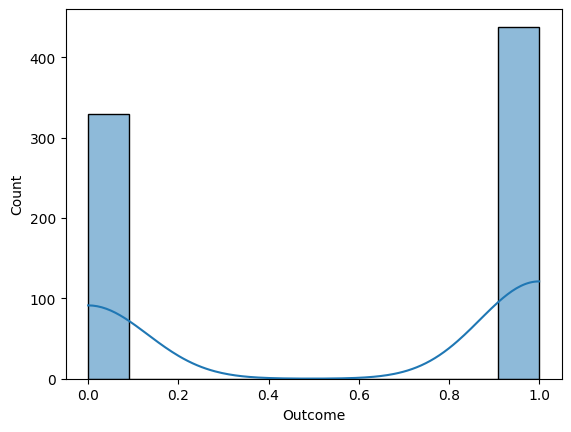

In [232]:
sns.histplot(df['Outcome'],kde=True)

<Axes: xlabel='Outcome', ylabel='count'>

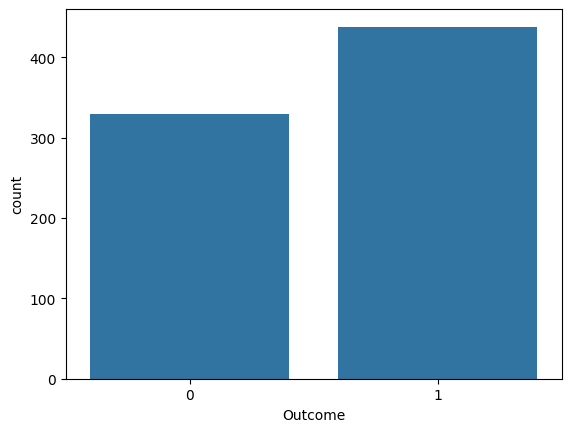

In [233]:
sns.countplot(x=df['Outcome'])

<Axes: xlabel='Outcome'>

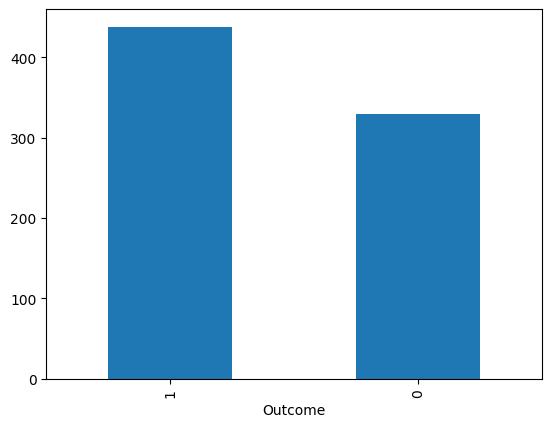

In [234]:
df['Outcome'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

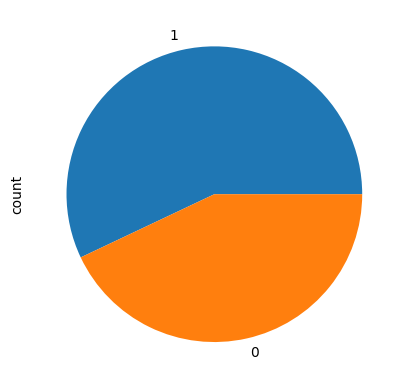

In [235]:
df['Outcome'].value_counts().plot(kind='pie')


<Axes: >

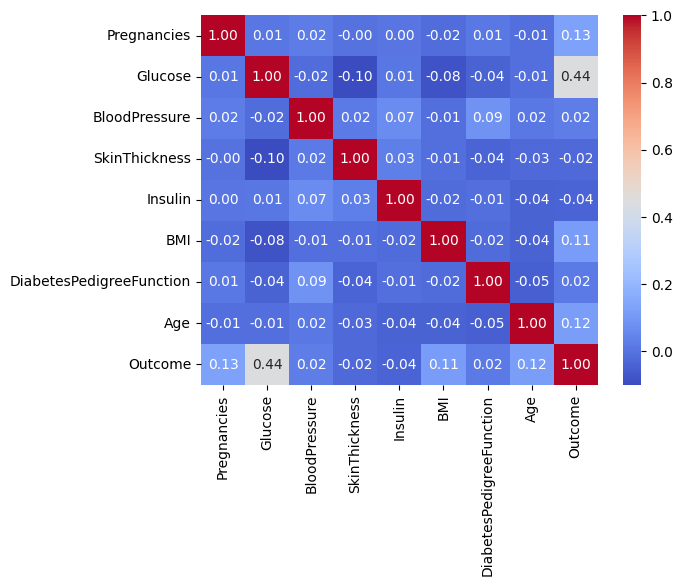

In [236]:
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm')

In [237]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']


In [238]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [239]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [240]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_train_data, X_test_data, y_train_data, y_test_data):
    model.fit(X_train_data, y_train)

    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)

    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1 Score": f1_score(y_test, y_test_pred)
    }

In [241]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        X_train_scaled,
        X_test_scaled
    ),

    "KNN": (
        KNeighborsClassifier(),
        X_train_scaled,
        X_test_scaled
    ),

    "GaussianNB": (
        GaussianNB(),
        X_train,
        X_test
    ),

    "AdaBoost": (
        AdaBoostClassifier(
            n_estimators=50,
            learning_rate=1.0,
            random_state=42),
        X_train,
        X_test
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(
            n_estimators=10,
            learning_rate=0.03,
            random_state=42),
        X_train,
        X_test
    ),

    "XGBoost": (
        XGBClassifier(
            n_estimators=10,
            learning_rate=0.05,
            random_state=42,
            max_depth=2,
            eval_metric="logloss"
        ),
        X_train,
        X_test
    )
}

In [242]:
results = []

for name, (model, X_train_data, X_test_data) in models.items():

    scores = evaluate_model(
        model,
        X_train_data,
        X_test_data,
        y_train,
        y_test
    )

    scores["Model"] = name
    results.append(scores)

results_df = pd.DataFrame(results)


results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Model
5,0.706840,0.694805,0.672269,0.909091,0.772947,XGBoost
2,0.700326,0.727273,0.744681,0.795455,0.769231,GaussianNB
4,0.666124,0.655844,0.627737,0.977273,0.764444,Gradient Boosting
0,0.701954,0.701299,0.705882,0.818182,0.757895,Logistic Regression
3,0.732899,0.681818,0.701031,0.772727,0.735135,AdaBoost
1,0.781759,0.623377,0.653061,0.727273,0.688172,KNN


In [243]:
from sklearn.metrics import classification_report, confusion_matrix

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred = gnb.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[42 24]
 [18 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.64      0.67        66
           1       0.74      0.80      0.77        88

    accuracy                           0.73       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.73      0.73      0.73       154



In [244]:
xgb = XGBClassifier(
            n_estimators=10,
            learning_rate=0.05,
            random_state=42,
            max_depth=2,
            eval_metric="logloss"

)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[27 39]
 [ 8 80]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.41      0.53        66
           1       0.67      0.91      0.77        88

    accuracy                           0.69       154
   macro avg       0.72      0.66      0.65       154
weighted avg       0.71      0.69      0.67       154



In [245]:
import joblib


joblib.dump(gnb,'diabetes_model.pkl')

['diabetes_model.pkl']